<a href="https://colab.research.google.com/github/Diego-Cano-bit/CIMAT-Monterrey/blob/main/Spectograms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pathlib #librería para cargar datos
import numpy as np
import pandas as pd
import re
from scipy.fftpack import fft, ifft
import scipy
from scipy.signal import butter,lfilter,freqz
import matplotlib.pyplot as plt

ejemplo_dir = '/content/drive/MyDrive/Colab Notebooks/PYTHON/PICOS_LOCALIZADOS' #carpeta donde están los datos
#tiene que estar en la nube con permisos ilimitado
sample_inverted=-1*ejemplo_dir
directorio = pathlib.Path(ejemplo_dir)
nombres=[]

for fichero in directorio.iterdir():
  nombres.append(fichero.name)
  r = re.compile(r"(\d+)")  #se ordenan los nombres
  nombres.sort (key=lambda x: int(r.search(x).group(1)))
  print(nombres)

señales=[] #nuevo arreglo de señales ordenados

for i in range(0,len(nombres)):
 for fichero in directorio.iterdir():
   if fichero.name==nombres[i]:
   # print("true")
    datos=pd.read_csv(fichero,names=[fichero.name])
    señales.append(datos)

def butter_lowpass(cutoff, fs, order=5):
    return butter(order, cutoff, fs=fs, btype='low', analog=False)

def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y

cutoff = 3.667 #cutoff frequency in rad/s
fs = 15 #sampling frequency in rad/s
order = 60 #order of filter

y = butter_lowpass_filter(señales[i], cutoff, fs, order)
plt.plot(señales[0])

####SUAVIZADO DE LA SEÑAL####
smooth = scipy.signal.savgol_filter(y, 21, 7, mode='nearest')


['0001.txt']
['0001.txt', '0002.txt']
['0001.txt', '0002.txt', '0003.txt']
['0001.txt', '0002.txt', '0003.txt', '0004.txt']
['0001.txt', '0002.txt', '0003.txt', '0004.txt', '0012.txt']
['0001.txt', '0002.txt', '0003.txt', '0004.txt', '0012.txt', '0013.txt']
['0001.txt', '0002.txt', '0003.txt', '0004.txt', '0012.txt', '0013.txt', '0014.txt']
['0001.txt', '0002.txt', '0003.txt', '0004.txt', '0012.txt', '0013.txt', '0014.txt', '0015.txt']
['0001.txt', '0002.txt', '0003.txt', '0004.txt', '0012.txt', '0013.txt', '0014.txt', '0015.txt', '0016.txt']
['0001.txt', '0002.txt', '0003.txt', '0004.txt', '0012.txt', '0013.txt', '0014.txt', '0015.txt', '0016.txt', '0017.txt']
['0001.txt', '0002.txt', '0003.txt', '0004.txt', '0012.txt', '0013.txt', '0014.txt', '0015.txt', '0016.txt', '0017.txt', '0018.txt']
['0001.txt', '0002.txt', '0003.txt', '0004.txt', '0012.txt', '0013.txt', '0014.txt', '0015.txt', '0016.txt', '0017.txt', '0018.txt', '0019.txt']
['0001.txt', '0002.txt', '0003.txt', '0004.txt', '00

AttributeError: ignored

In [ ]:
distancia=[]
for i in range(0,len(señales)):
  dist1=[]

  for j in range(0,len(señales[i])-1):
    dist1.append(float(np.array(señales[i])[j+1])-float(np.array(señales[i])[j]))
  distancia.append(dist1)



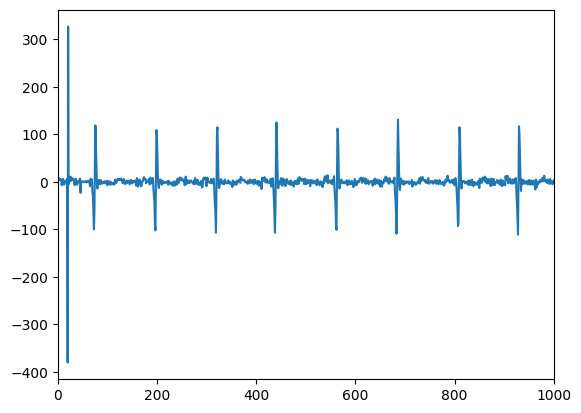

In [ ]:
distancia=np.array(dist1)
plt.xlim(0,1000)
plt.plot(dist1)

In [ ]:
from scipy.fftpack import fft, ifft
x = fft(distancia[1])
N = len(x)
n = np.arange(N)
sr = 195
T = N/sr
freq = n/T

# Get the one-sided specturm
n_oneside = N//2
# get the one side frequency
f_oneside = freq[:n_oneside]

plt.figure(figsize = (11.5, 6))
plt.plot(f_oneside[1:-1], np.abs(x[:n_oneside])[1:-1], 'b')
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.show()

plt.figure(figsize = (11.5, 6))
plt.plot(np.log(f_oneside[1:]), np.log(np.abs(x[:n_oneside])[1:]), 'b')
plt.xlabel('log(Freq (Hz))')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.show()


(230400,)


<ipython-input-13-a43162cc4865>:8: UserWarning: Only one segment is calculated since parameter NFFT (=256) >= signal length (=81).
  fig=plt.specgram(np.array(imagen).flatten(), Fs=195, cmap="gray")


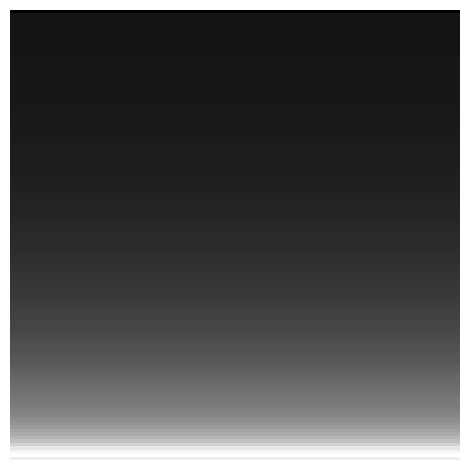

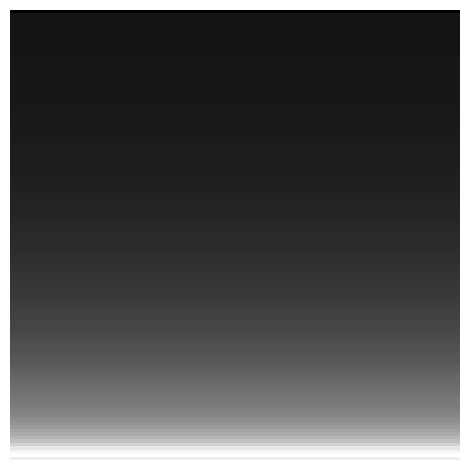

In [ ]:
from numpy.lib import shape_base
import math
import matplotlib.pyplot as plt
from PIL import Image as im

def image_to_array(imagen):
    plt.figure(figsize=(4.8,4.8))
    fig=plt.specgram(np.array(imagen).flatten(), Fs=195, cmap="gray")
    fig=plt.axis("off")
    fig=plt.tight_layout()
    fig = plt.gcf()
    fig.canvas.draw()
    arr = np.array(fig.canvas.renderer.buffer_rgba())
    gray_arr = np.dot(arr[..., :3], [0.2989, 0.5870, 0.1140])

# Guarda la imagen en un arreglo
    return(gray_arr.flatten())
image_to_array(y)
spectogram_muestra = image_to_array(y)
print(spectogram_muestra.shape)
height, width = y.shape[:2]

In [ ]:
y=pd.read_excel("/content/drive/MyDrive/Colab Notebooks/electros/DATOS SELECCIONADOS (1).xlsx",header=None).dropna()
y=np.array(y[1])